<div style="background: linear-gradient(to bottom, #461EBE, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Dataset Exploration — `data/icons_filtered.jsonl`
Explores the 275,912 license-filtered icons: monochrome vs. multicolor split,
path count distribution, and SVG string length.

</div>

In [32]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, white, black, dark_bg

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor":  dark_bg,
    "axes.facecolor":    dark_bg,
    "axes.edgecolor":    blue,
    "axes.labelcolor":   white,
    "xtick.color":       white,
    "ytick.color":       white,
    "text.color":        white,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  blue,
    "legend.facecolor":  dark_bg,
    "font.family":       "sans-serif",
})

In [33]:
DATA = Path("../data/icons_filtered.jsonl")

records = []
with open(DATA) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

print(f"Total icons loaded: {len(records):,}")

Total icons loaded: 275,912


## 1. Monochrome vs. Multicolor Split

In [34]:
mono  = [r for r in records if not r["is_multicolor"]]
multi = [r for r in records if r["is_multicolor"]]

total = len(records)
print(f"Monochrome : {len(mono):>7,}  ({len(mono)/total*100:.1f}%)")
print(f"Multicolor : {len(multi):>7,}  ({len(multi)/total*100:.1f}%)")
print(f"Total      : {total:>7,}")

Monochrome : 227,040  (82.3%)
Multicolor :  48,872  (17.7%)
Total      : 275,912


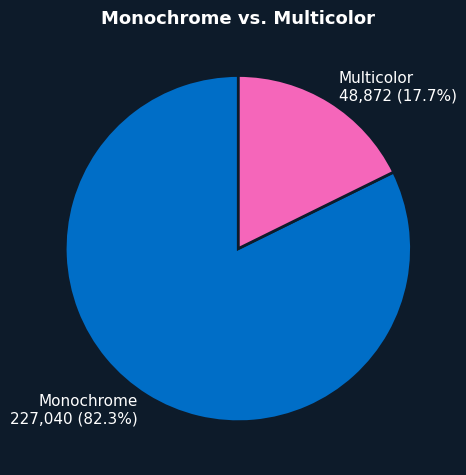

In [42]:
fig, ax = plt.subplots(figsize=(5, 5), facecolor=dark_bg)
ax.pie(
    [len(mono), len(multi)],
    labels=[
        f"Monochrome\n{len(mono):,} ({len(mono)/total*100:.1f}%)",
        f"Multicolor\n{len(multi):,} ({len(multi)/total*100:.1f}%)",
    ],
    colors=[blue, pink],
    startangle=90,
    wedgeprops=dict(linewidth=2, edgecolor=dark_bg),
    textprops=dict(color=white, fontsize=11),
)
ax.set_title("Monochrome vs. Multicolor", fontsize=13, color=white, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Average Path Count

In [36]:
mono_paths  = np.array([r["path_count"] for r in mono])
multi_paths = np.array([r["path_count"] for r in multi])

print(f"{'':12s}  {'mean':>6}  {'median':>6}  {'max':>6}")
print("-" * 36)
print(f"{'Monochrome':12s}  {mono_paths.mean():6.1f}  {np.median(mono_paths):6.1f}  {mono_paths.max():6,}")
print(f"{'Multicolor':12s}  {multi_paths.mean():6.1f}  {np.median(multi_paths):6.1f}  {multi_paths.max():6,}")

                mean  median     max
------------------------------------
Monochrome       1.4     1.0      40
Multicolor       9.9     4.0     895


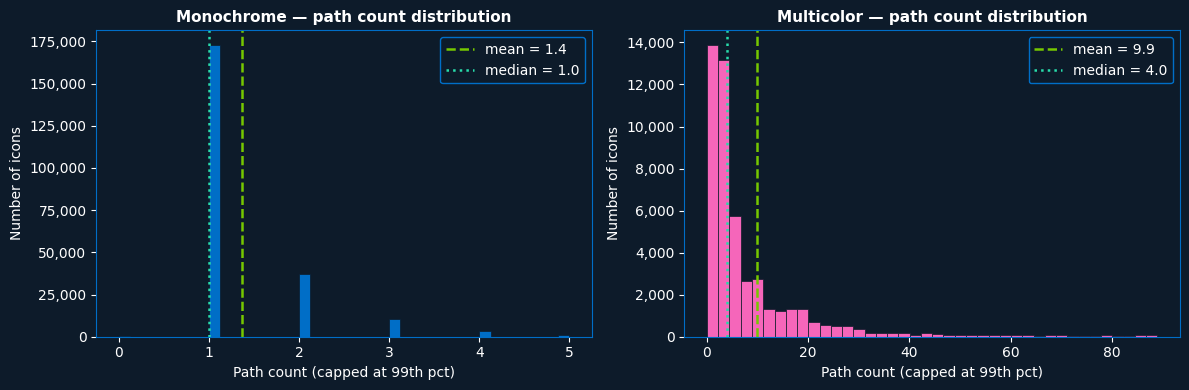

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=dark_bg)

for ax, paths, label, color in zip(
    axes,
    [mono_paths, multi_paths],
    ["Monochrome", "Multicolor"],
    [blue, pink],
):
    cap = int(np.percentile(paths, 99))
    ax.hist(paths[paths <= cap], bins=40, color=color, edgecolor=dark_bg, linewidth=0.5)
    ax.axvline(paths.mean(), color=green, linestyle="--", linewidth=1.8,
               label=f"mean = {paths.mean():.1f}")
    ax.axvline(np.median(paths), color=teal, linestyle=":", linewidth=1.8,
           label=f"median = {np.median(paths):.1f}")
    ax.set_title(f"{label} — path count distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel("Path count (capped at 99th pct)")
    ax.set_ylabel("Number of icons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Average SVG String Length

In [38]:
mono_len  = np.array([len(r["svg"]) for r in mono])
multi_len = np.array([len(r["svg"]) for r in multi])

print(f"{'':12s}  {'mean':>8}  {'median':>8}  {'max':>8}  chars")
print("-" * 50)
print(f"{'Monochrome':12s}  {mono_len.mean():8.0f}  {np.median(mono_len):8.0f}  {mono_len.max():8,}")
print(f"{'Multicolor':12s}  {multi_len.mean():8.0f}  {np.median(multi_len):8.0f}  {multi_len.max():8,}")

                  mean    median       max  chars
--------------------------------------------------
Monochrome         678       497   155,610
Multicolor        4105      1284   869,523


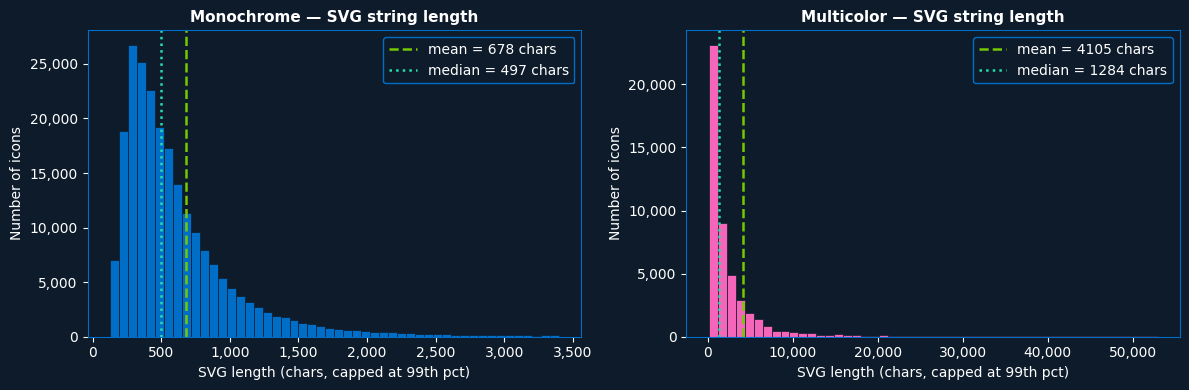

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=dark_bg)

for ax, lengths, label, color in zip(
    axes,
    [mono_len, multi_len],
    ["Monochrome", "Multicolor"],
    [blue, pink],
):
    cap = int(np.percentile(lengths, 99))
    ax.hist(lengths[lengths <= cap], bins=50, color=color, edgecolor=dark_bg, linewidth=0.5)
    ax.axvline(lengths.mean(), color=green, linestyle="--", linewidth=1.8,
               label=f"mean = {lengths.mean():.0f} chars")
    ax.axvline(np.median(lengths), color=teal, linestyle=":", linewidth=1.8,
               label=f"median = {np.median(lengths):.0f} chars")
    ax.set_title(f"{label} — SVG string length", fontsize=11, fontweight="bold")
    ax.set_xlabel("SVG length (chars, capped at 99th pct)")
    ax.set_ylabel("Number of icons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Summary Table

In [53]:
import pandas as pd

summary = pd.DataFrame({
    "Category":            ["Monochrome", "Multicolor"],
    "Count":               [len(mono), len(multi)],
    "Share (%)": [f"{len(mono)/total*100:.1f}", f"{len(multi)/total*100:.1f}"],
    "Avg paths":           [f"{mono_paths.mean():.1f}", f"{multi_paths.mean():.1f}"],
    "Median paths":        [f"{np.median(mono_paths):.1f}", f"{np.median(multi_paths):.1f}"],
    "Avg SVG len (chars)": [f"{mono_len.mean():.0f}", f"{multi_len.mean():.0f}"],
    "Median SVG len":      [f"{np.median(mono_len):.0f}", f"{np.median(multi_len):.0f}"],
})

summary.set_index("Category", inplace=True)
summary

,Count,Share (%),Avg paths,Median paths,Avg SVG len (chars),Median SVG len
Category,,,,,,
Monochrome,227040,82.3,1.4,1.0,678,497
Multicolor,48872,17.7,9.9,4.0,4105,1284
